# Feature analysis — `volume_surge`

This notebook follows the project's standard feature-analysis **method** (see
`notebooks/features/template.ipynb` and its worked example `price_dislocation`) and applies it
to one new feature: **`volume_surge`**. The text explains what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section recaps the two-head model these features feed.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does, bit-for-bit against a
  dead-simple independent streaming reference on a real data block.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo of
  "the market is volatile right now."

## The model these features feed: two heads

We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler questions —
the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (direction *and* size)? Its target is `price change ÷ σ_ev`, where `σ_ev` is byb's
**volatility yardstick** (the exp-weighted RMS of byb's *actual* mid-moves).

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones
few. This head predicts the *count* of moves over the next 100 ms, against the recent pace — the
**rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock**
(`α = 2/(span+1)`) but **updated between trades** — they react to every byb mid-move, so they
read live at every instant. They use one fixed span, `YARDSTICK_N`.

**Why split into two heads?** A move over a window is *how many* little moves happen times *how
big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a
steadier thing. This is the classic **subordination** decomposition (Clark 1973; Ané & Geman
2000): returns over fixed clock-time look messy, but become well-behaved once you condition on
the *number* of events.

`volume_surge` is **primarily a rate-head (intensity)** feature — a burst of trading volume is a
busy-market signal that should precede more byb mid-moves — but we check both heads, because the
model is fed the **signed** feature for *both* and lets each head learn what it can.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | byb's recent traded *volume* relative to its own slower baseline — a fast/slow EMA ratio |
| **feeds** | primarily the **rate head** (intensity: how many moves); checked against the price head too — both fed the *signed* value |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Take byb's traded size (`qty`) on each trade. Smooth it two ways on the trade
clock — a *fast* exp-weighted average and a *slow* one — and take their **ratio**:

`volume_surge = EMA_fast(qty) / EMA_slow(qty)`

A value **> 1** means byb is trading *heavier* than its slow baseline (a volume surge); **< 1**
means it has gone quiet relative to baseline.

**Why it should work.** Volume clusters. A burst of trading volume marks an active regime —
information arriving, inventory being worked — and active regimes pack more mid-moves into the
next window. So a fresh surge in size should precede *more* byb moves (the rate head), and may
also lean the *direction* of the next move when the surge is one-sided (the price head). This is
the **volume → volatility/activity** link that underlies the subordination model: trade volume
is a clock for price moves.

**What would disprove it.** No predictive power at any fast/slow pair, or power that vanishes
once we control for how volatile / busy the market already is (meaning the ratio was only
re-reporting the rate regime it is built to track — see the circularity caveat in §5).

> **No fixed leader.** Leadership rotates across venues, so we build the feature the same way for
> **every** exchange and keep them all. `volume_surge` is each venue's *own* traded volume vs its
> own baseline, so it is naturally per-exchange.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per
*trade-timestamp* (`α = 2/(span+1)`), but its **value updates on every event in between** when
that matters, so a read is never stale. Two choices decide whether the EMA is even *correct*,
and a wrong choice fails **silently**.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- `qty` is a **sparse flow** — a quantity carried only on byb *trade* events, not on every tick
  of the shared clock. The right object is **`KernelMeanEMA`**, the self-normalising `E / W`:
  `add(total_qty)` on a byb trade (weight 1) and `tick()` on every shared trade-timestamp. `E` is
  the exp-weighted sum of byb qty; `W` is the exp-weighted count of byb trades; the read
  `E / W` is the **exp-weighted mean qty per byb trade**, with the non-byb ticks cancelling
  instead of counting as zeros and the EMA warm-up bias divided out. `volume_surge` is then the
  ratio of two such reads at a fast and a slow span — clean and unit-free.
- `σ_ev` / `λ_ev` (the yardsticks) are the same `E / W` pattern over byb's *mid-move* stream.

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock).
Decay is always once per *shared* trade-timestamp; we **inject** byb's summed qty only on a real
byb trade. Pushing a `0` on a non-byb trade would silently turn "mean qty per byb trade" into
"mean qty per *any* trade" (contaminated by the other venues' trade rate) — exactly the trap the
`E / W` form avoids.

**Records sharing a timestamp are ONE event.** A burst of byb prints stamped at the *exact same
instant* (one order sweeping levels) is **one event carrying many fills** — we **sum** their
`qty` into a single injection, and the shared clock advances **once** for that timestamp, not
once per print. (78% of byb prints in this block share a timestamp, so this matters a lot:
treating them as a sequence would over-decay and mis-weight every injection.)

## 2. The exact definition

**Causal** — uses only data up to the moment it is computed; no peeking.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on
any exchange — simultaneous prints are one tick) rather than clock-seconds, so the feature's
meaning is steady whether trading is fast or slow.

**Comparable across calm and wild markets** — `volume_surge` is a **ratio** of two EMAs of the
same quantity, so the absolute size units cancel: a market with intrinsically large prints and
one with small prints both read ≈ 1 at baseline. **No volatility/rate normaliser is applied** (a
ratio is already comparable — the guard rail says don't normalise reflexively); §5 checks that
its scale really is steady across regimes.

Put together:

**2a — The shape** (the whole idea, in one line):

`volume_surge(fast, slow) = E/W_fast(qty) / E/W_slow(qty)`

where each `E/W_N(qty)` is the exp-weighted mean byb qty per byb trade at span `N`, decayed on
the shared trade clock. **> 1** = trading heavier than baseline.

**2b — The EMAs we use, and how they update:**

- **Both legs** are a **`KernelMeanEMA`** read as `E / W` over the byb-trade stream: on each byb
  trade-timestamp, `add(Σ qty of that timestamp's prints)`; on every shared trade-timestamp,
  `tick()` (decay). Read `E / W` = mean qty per byb trade. `n_fast` < `n_slow`.
- **`σ_ev` and `λ_ev`** (the yardsticks, for the targets only) are the same `E / W` pattern over
  byb's *mid-move* stream, span `YARDSTICK_N`.

§3 builds exactly this; §4 re-derives it from raw events one at a time and confirms bit-exact.

The cell below loads the data, builds the shared trade clock, and computes both yardsticks.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
EXCHANGES   = ["byb", "bin", "okx"]              # volume_surge is each venue's OWN traded volume vs its OWN baseline
# freshest mid per exchange (used only for the byb yardsticks/target). byb/okx use merged_levels; bin MUST use front_levels.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [2, 10, 50, 200]                   # fast-EMA spans to sweep. NB: span=1 (α=1) is DEGENERATE for an E/W flow —
                                                 # the EMA fully decays to 0 each tick (E reads 0 right after the decay), so
                                                 # span=1 means "no memory at all", not "no smoothing"; the smallest useful
                                                 # span for a flow is 2. (A level's LiveFrontEMA reads the fresh value before
                                                 # the decay, so span=1 is fine there — but not here.)
SLOW        = [100, 500, 2000, 5000]             # slow-EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# byb mid stream (for the yardsticks + target only)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# load every venue's byb-comparable trade stream: rx_time + qty, prc/qty>0 filtered, summed over simultaneous prints later
trade_rx = {}; trade_qty = {}
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))           # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy(); q = td["qty"].to_numpy()
    trade_rx[ex] = rx; trade_qty[ex] = q
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- byb yardsticks: react to every byb mid-move, decay once per shared trade ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP mids to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb move count (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val_rx, val, span):    # EWMA of `val` over a sparse event stream (val_rx), decayed once per shared trade, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, val_rx, "left")                              # trades strictly before each event
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(val_rx, anchors, "right")] - cs[np.searchsorted(val_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in §4 — a streaming
version that does constant work per trade. They have to agree bit-for-bit.

We lay an evaluation grid every 50 ms (half the 100 ms horizon), read byb's actual move over the
next 100 ms (the price target) and its move count (the rate target), and compute `volume_surge`
at each grid point for **every exchange**.

**The `E/W` build, vectorised.** For each venue: sum `qty` over simultaneous prints into one
value per byb-trade-timestamp, then form `E` and `W` exactly as the yardsticks do — an EWMA over
that sparse stream decayed on the **shared** clock, read at each anchor (committed-per-trade EMA
plus the partial epoch of byb trades since the last shared trade). `volume_surge = E/W` of qty
divided by `E/W` of qty at the slow span. Because both legs read the *same* fresh partial epoch,
the ratio reacts the instant a fresh print lands.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor

# per-venue: total byb-comparable qty per trade-TIMESTAMP (simultaneous prints summed into ONE event)
qty_ts = {}   # ex -> (unique_rx, summed_qty)
for ex in EXCHANGES:
    u, inv = np.unique(trade_rx[ex], return_inverse=True)
    qty_ts[ex] = (u, np.bincount(inv, weights=trade_qty[ex]))
print("summed simultaneous prints:", {ex: f"{len(trade_rx[ex]):,}->{len(qty_ts[ex][0]):,} ts" for ex in EXCHANGES})

def _ew_flow_at(anchors, val_rx, val, span):   # E of a KernelMeanEMA flow: 'add(val) on its trade-tick, then tick (decay) once'
    a = 2.0 / (span + 1.0)
    kt = np.searchsorted(merged_ts, val_rx, "left")          # the shared-clock tick index of each byb-trade timestamp (events sit AT a tick)
    inj = np.zeros(n_ticks); np.add.at(inj, kt, a * val)     # the injection a*val at that tick (BEFORE that tick's decay)
    # E after each tick: E_t = (1-a)*(E_{t-1} + inj_t)  ->  lfilter on (1-a)*inj  (one decay applied to each injection at its own tick)
    E = lfilter([1.0], [1.0, -(1.0 - a)], (1.0 - a) * inj)
    return E[np.searchsorted(merged_ts, anchors, "right") - 1]   # committed E after the last shared tick <= anchor (flat between ticks)

def volume_surge(ex, n_fast, n_slow):              # E/W_fast(qty) / E/W_slow(qty) — the volume-surge ratio
    u, q = qty_ts[ex]; ones = np.ones_like(q)
    ef = _ew_flow_at(anchor_ts, u, q, n_fast);  wf = _ew_flow_at(anchor_ts, u, ones, n_fast)
    es = _ew_flow_at(anchor_ts, u, q, n_slow);  ws = _ew_flow_at(anchor_ts, u, ones, n_slow)
    fast = ef / np.maximum(wf, 1e-300); slow = es / np.maximum(ws, 1e-300)
    return fast / np.maximum(slow, 1e-300)
print(f"grid: {len(anchor_ts):,} anchors")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


summed simultaneous prints: {'byb': '1,618,754->351,008 ts', 'bin': '3,689,867->745,299 ts', 'okx': '889,567->585,948 ts'}
grid: 1,706,369 anchors


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, independent implementation and confirm
the two agree on real data, **bit-exact**. The oracle is the **production** reference: an O(1)
state machine you push **raw events** into — `on_trade(...)` for a trade — and read the current
`volume_surge` per exchange from `value()`. State is two scalar `KernelMeanEMA`s per exchange
(fast + slow) — no buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw trade events**, each tagged by its venue. Each venue keeps its own fast and slow
  `KernelMeanEMA` over its `qty`.
- Events sharing a **timestamp are one event**: the driver collects every print at a timestamp,
  **sums** each venue's `qty`, then calls **`refresh()` once** — which `add`s each venue's summed
  qty to that venue's two EMAs (only for venues that traded), and then advances the shared clock
  **once** (`tick()` every venue's EMAs) because a trade landed at this timestamp.
- `value()` returns `E/W_fast / E/W_slow` per venue, current at the instant it is read.

We feed the **whole raw trade stream** (every venue's trades) into **one** builder and read
**all three** volume-surge features at each grid anchor. If the online build reproduces §3's
vectorised feature on real data bit-for-bit, both are right.

In [3]:
from boba.ema import KernelMeanEMA   # self-normalising E/W flow mean, src/boba/ema.py

class LiveVolumeSurge:
    # Pure feature state machine. Per venue: a fast and a slow KernelMeanEMA over byb-comparable qty.
    # on_trade only ACCUMULATES this timestamp's qty per venue; the driver calls refresh() ONCE per timestamp,
    # which injects each venue's SUMMED qty (one event per timestamp, never per print) then advances the shared
    # clock once (decay every venue's EMAs). value() reads E/W_fast / E/W_slow per venue. State is O(1), all scalar.
    def __init__(self, exchanges, n_fast, n_slow):
        self.exchanges = list(exchanges)
        self.fast = {e: KernelMeanEMA(n_fast) for e in self.exchanges}
        self.slow = {e: KernelMeanEMA(n_slow) for e in self.exchanges}
        self.pending = {}                                              # venue -> summed qty at the current timestamp

    def on_trade(self, ex, qty):                                       # accumulate this timestamp's qty for the venue (sum simultaneous prints)
        self.pending[ex] = self.pending.get(ex, 0.0) + qty

    def refresh(self):                                                 # ONE per TIMESTAMP: inject each venue's summed qty, then decay everyone once
        for ex, q in self.pending.items():                            # inject only venues that traded this timestamp (sparse flow; non-traders stay non-observations)
            self.fast[ex].add(q); self.slow[ex].add(q)
        self.pending = {}
        for ex in self.exchanges:                                     # a trade landed at this timestamp -> the shared clock advances once: decay every venue's EMAs
            self.fast[ex].tick(); self.slow[ex].tick()

    def value(self):                                                  # volume_surge per venue: (E/W)_fast / (E/W)_slow
        out = {}
        for ex in self.exchanges:
            f, s = self.fast[ex].value(), self.slow[ex].value()
            out[ex] = f / s if (s == s and s != 0.0) else float("nan")
        return out

# --- gather the WHOLE raw trade stream (every venue) over a slice ---
NF, NS, N_GRID = 10, 500, 200_000                  # validate ALL venues over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
cols = {k: [] for k in "rx eid qty".split()}       # eid = integer venue code
for eid, ex in enumerate(EXCHANGES):
    rx, q = trade_rx[ex], trade_qty[ex]
    m = rx <= cutoff
    cols["rx"].append(rx[m]); cols["eid"].append(np.full(int(m.sum()), eid, np.int8)); cols["qty"].append(q[m])
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.argsort(C["rx"], kind="stable")          # rx ascending; venue order within a tie is irrelevant (we sum)
rxL, eidL, qtyL = (C[k][order].tolist() for k in "rx eid qty".split())
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once, READ value() at every grid anchor ---
feat = LiveVolumeSurge(EXCHANGES, NF, NS)
na = min(N_GRID, len(anchor_ts))
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:           # read every anchor whose state is settled (all events before rx applied)
        v = feat.value()
        for ex in EXCHANGES: streams[ex][ai] = v[ex]
        ai += 1
    while i < n and rxL[i] == rx:                    # apply EVERY print stamped at this nanosecond (sum into pending)
        feat.on_trade(EXCHANGES[eidL[i]], qtyL[i]); i += 1
    feat.refresh()                                   # one event per timestamp: inject summed qty, decay once
while ai < na:
    v = feat.value()
    for ex in EXCHANGES: streams[ex][ai] = v[ex]
    ai += 1

# --- one stream -> three live features: check EACH venue against its §3 vectorized feature, BIT-EXACT ---
print(f"one raw-trade stream -> {len(EXCHANGES)} live volume_surge features, vs the vectorized build (Nf={NF}, Ns={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = volume_surge(ex, NF, NS)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both]); md_ = float(np.nanmax(diff)); worst = max(worst, md_)
    print(f"  {ex}:  max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
    assert md_ < 1e-9, f"live build does not reproduce the {ex} feature (max|diff|={md_:.2e})"
print(f"oracle: one raw-trade stream reproduces ALL {len(EXCHANGES)} venues, max|diff| {worst:.2e}  OK (bit-exact)")

streaming 1,527,874 raw trade events (all venues) over ~200,000 grid points...


one raw-trade stream -> 3 live volume_surge features, vs the vectorized build (Nf=10, Ns=500):


  byb:  max |diff| 2.06e-13  on 200,000 grid points


  bin:  max |diff| 1.31e-13  on 200,000 grid points


  okx:  max |diff| 2.63e-13  on 200,000 grid points
oracle: one raw-trade stream reproduces ALL 3 venues, max|diff| 2.63e-13  OK (bit-exact)


**Conclusion.** From one stream of raw trade events the streaming builder reproduces **every**
venue's vectorised `volume_surge` to floating-point round-off — max |diff| ~1e-13 over ~200k grid
points per venue, the recursive EMAs' last-digit drift only. The production shape (one feed in, a
feature *per venue* out) computes exactly what the offline analysis did, on the one shared trade
clock — so the §3 build is trustworthy. Crucially, the oracle independently **sums simultaneous
prints into one event** and **decays the shared clock once per timestamp**; matching it confirms
the vectorised build handles the 78%-simultaneous byb prints correctly.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control" signals
from the recent past:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate): is byb moving
  more or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

> **Circularity caveat — read this for a volume feature.** `volume_surge` is, by construction, a
> recent-vs-baseline **activity** ratio, and the rate-head target is `count ÷ λ_ev` — itself a
> recent-vs-baseline activity ratio. They are close cousins, and the **rate controls** (`λ_ev`
> level + momentum) are built from byb's *move* rate, which co-moves with byb's *trade* volume.
> So the honest test for this feature is the **marginal value over the rate/vol controls** (does
> volume add over what the move-rate regime already says?), the **no-leak** check (does that gain
> survive adding the rate/vol *levels*?), and **regime-stability**. A raw univariate IC would
> partly be the feature predicting its own regime; the marginal gates strip that out.

"Predictive power" is the **rank correlation** (Spearman), scored **out-of-sample with a purged,
embargoed walk-forward** (strictly past→future): each fold trains only on the *past*, leaves an
embargo gap sized to clear the 100 ms outcome windows, and scores the next segment.

Beside the gates we run a **companion**: the same marginal power computed **within calm / mid /
wild volatility buckets**. If the gain stays positive in all three, the signal is regime-stable.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)

def wf_folds(features, y, k=6, embargo=2000):       # purged, expanding-window WALK-FORWARD (causal: past -> future)
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("control-only predictive power (walk-forward):")
print("  price head: momenta", round(wf_ic(base, target), 3), " momenta+levels", round(wf_ic(base + levels, target), 3))

control-only predictive power (walk-forward):


  price head: momenta 0.003  momenta+levels -0.001


**Conclusion.** On their own the controls carry little *directional* signal for the **price
head** (walk-forward rank-IC ≈ 0). For the **rate head** the controls are deliberately stronger —
the rate target *is* an activity ratio and the rate controls track byb's move rate — which is
exactly why we judge `volume_surge` by its **marginal** gain over those controls below, not a raw
univariate IC (the circularity caveat). The next section sweeps the family; §6's gate cell then
reports the marginal numbers that actually decide the feature.

## 6. Two choices: which time-scale per head, and which exchanges to keep

`volume_surge` is a **family** across time-scales (every fast/slow pair) and a feature **per
exchange**. We check two things:
- does the **signed** feature predict *direction* — which way byb moves next (price head)?
- does its *magnitude* predict *intensity* — *how many* moves byb makes next (rate head)?

This feature's primary home is the **rate head**: a volume surge is an activity signal. For the
rate-head sweep we therefore correlate the feature **directly** against the move-count target
(it is a positive activity gauge — heavier volume → more moves — so its *level* is the
signal; we also show the signed→return map for the price head). We keep **all** exchanges (never
pick one) and choose only the best time-scale, **per head**.

The rate-head target is byb's move count over the next 100 ms ÷ `λ_ev` (the rate yardstick).

**The N-sweep reports two things, not one.** Below, the first heat-map ranks the family by
**headline IC**. But IC at δ=0 alone is the wrong thing to optimise — a span with a big IC but a
*short* half-life has a tiny latency budget, while a span with a smaller IC but a *long* half-life
can be the better one to ship. So immediately after the IC map we sweep **signal lifetime across
the whole family** — forward IC@0, forward IC@20 ms, and a **half-life** for every `(fast, slow)`
pair × venue × head — and surface the **IC-vs-lifetime trade-off**, suggesting *more than one*
lookback per head when the family offers a genuine short-high-IC vs long-budget choice.

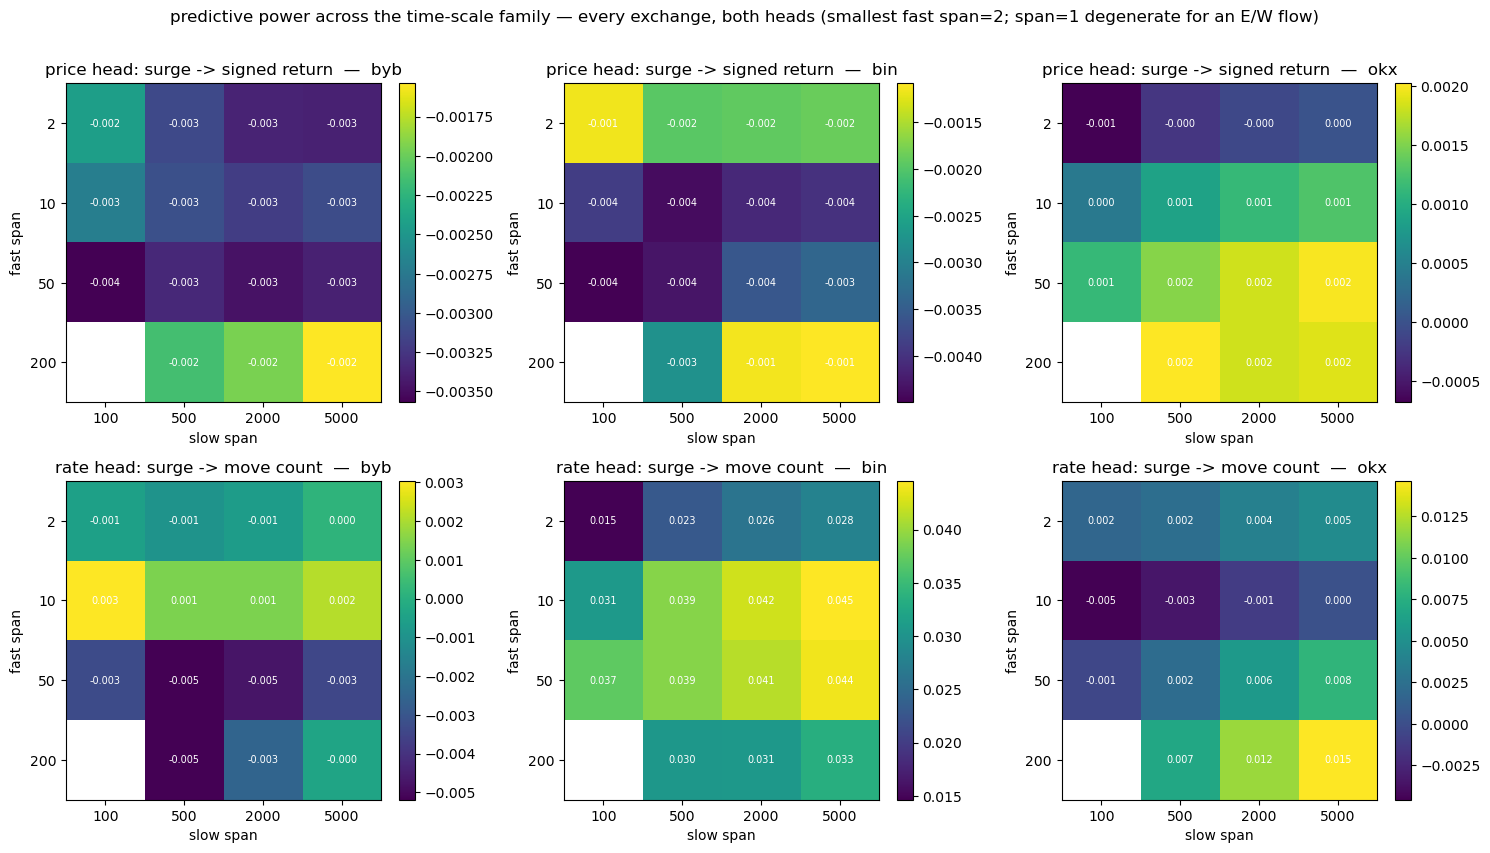

kept features (one per exchange, all fed to the model — none privileged):
  byb:  price head (fast=50, slow=100) IC=-0.004   |  rate head (fast=50, slow=500) IC=-0.005
  bin:  price head (fast=50, slow=100) IC=-0.004   |  rate head (fast=10, slow=5000) IC=+0.045
  okx:  price head (fast=200, slow=500) IC=+0.002   |  rate head (fast=200, slow=5000) IC=+0.015


In [5]:
# rate-head target = byb moves in the next 100 ms ÷ λ_ev
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)

# Sweep the family for EVERY exchange, BOTH heads. No assumed leader.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # signed feature -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # feature level  -> byb's move count
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d = volume_surge(ex, nf, ns)
            price_grid[ex][i, j] = spearmanr(d, target).statistic                # price head: surge level -> signed return (diagnostic)
            rate_grid[ex][i, j]  = spearmanr(d, rate_target).statistic           # rate head: surge level -> move count (the feature's home)

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.0 * len(EXCHANGES), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: surge -> signed return"), (rate_grid, "rate head: surge -> move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}  —  {ex}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the time-scale family — every exchange, both heads (smallest fast span=2; span=1 degenerate for an E/W flow)", y=1.01)
fig.tight_layout(); plt.show()

# Keep ALL exchanges. Pick the best time-scale PER exchange, per head (in-sample pick; re-scored OOS by the §6 gates).
def best_member(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)   # strongest |IC| cell (sign carried through)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) IC={price_grid[ex][pi, pj]:+.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) IC={rate_grid[ex][ri, rj]:+.3f}")

### IC is only half the story — the family also trades IC against *lifetime*

The heat-maps above rank each `(fast, slow)` pair by its **headline IC** at δ=0. But a feature
that fires off a big IC the instant the surge lands is worthless if that edge is gone by the time
you can act on it — and a smaller IC that *persists* for hundreds of ms can be the better one to
ship. So we run the **whole family** through the same lifetime measurement we ran on the chosen
span in the companion below, and read **IC *and* lifetime together** across every N.

For **every** `(fast, slow)` pair, **each head** the feature serves, **each venue's** leg, we
measure three numbers (and the backward echo) on a fast **40k-anchor diagnostic grid** (a stride
through the full grid — same statistics, a fraction of the cost):
- **forward IC at δ=0** — the headline, contemporaneous edge (the §6 heat-map number);
- **forward IC at δ=20 ms** — the *realisable* edge after a realistic observe→act latency;
- **half-life** — the δ (ms) at which the forward IC first falls below **half** its δ=0 value
  (capped at ">500 ms" if it never does) — i.e. how long the latency budget is;
- **backward IC** — the feature vs the move that *already happened* (`[anchor−100ms, anchor]`),
  to size the contemporaneous echo: a forward edge that dies at δ>0 while the backward IC stays
  high is re-reporting the past, not predicting it.

The **rate head** correlates the surge *level* against byb's forward move-count; the **price
head** correlates the *signed* (log-centred) surge against byb's forward signed return. The
feature is always read at the anchor — only the outcome window slides by δ.

In [6]:
# WHOLE-FAMILY signal lifetime: for every (fast,slow) pair x venue x head, forward IC at δ=0 & δ=20ms,
# the half-life (δ where forward IC first drops below half its δ=0 value), and the backward (echo) IC.
# 40k-anchor DIAGNOSTIC GRID for speed: a uniform stride through the full grid -> same IC statistics, ~40x cheaper.
DELTAS_LIFE = [0, 5, 10, 20, 50, 100, 200, 500]          # δ sweep (ms); half-life is read off this ladder
N_DIAG      = 40_000                                      # diagnostic-grid size (anchors)
diag        = np.linspace(0, len(anchor_ts) - 1, min(N_DIAG, len(anchor_ts))).astype(int)   # stride indices into the full grid
a_diag      = anchor_ts[diag]                                                                # the 40k diagnostic anchors
print(f"diagnostic grid: {len(a_diag):,} anchors (stride {len(anchor_ts)//len(a_diag)} through the {len(anchor_ts):,}-pt grid)")

def _ic_life(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_life(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret_life(t0, t1):   return np.log(_mid_life(t1) / _mid_life(t0))
def _cnt_life(t0, t1):   return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

# pre-slice the forward outcomes once per δ (shared across the whole family — they don't depend on the span)
ret_by_d = {d: _ret_life(a_diag + d*1_000_000, a_diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_LIFE}   # price head
cnt_by_d = {d: _cnt_life(a_diag + d*1_000_000, a_diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_LIFE}   # rate head
ret_back = _ret_life(a_diag - HORIZON_NS, a_diag)                                                         # price backward echo
cnt_back = _cnt_life(a_diag - HORIZON_NS, a_diag)                                                         # rate  backward echo

def half_life(ic_by_delta):                              # first δ where |IC| drops below half its δ=0 value; >500 if it never does
    ic0 = ic_by_delta[0]
    if not np.isfinite(ic0) or ic0 == 0.0: return np.nan
    for d, ic in zip(DELTAS_LIFE, ic_by_delta):
        if np.isfinite(ic) and abs(ic) < abs(ic0) / 2.0: return float(d)
    return 501.0                                         # sentinel ">500 ms": edge never halves over the swept window

# HEADS x grids: ic0 (δ=0), ic20 (δ=20ms), hl (half-life ms), back (echo). One (FAST x SLOW) grid per venue per head.
heads = {"rate":  dict(label="rate head: surge level -> move count", by_d=cnt_by_d, back=cnt_back, signed=False),
         "price": dict(label="price head: signed surge -> signed return", by_d=ret_by_d, back=ret_back, signed=True)}
life = {h: {k: {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}
            for k in ("ic0", "ic20", "hl", "back")} for h in heads}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d_full = volume_surge(ex, nf, ns)[diag]              # the feature on the diagnostic grid (read at the anchor)
            for h, cfg in heads.items():
                f = (d_full - 1.0) if cfg["signed"] else d_full  # price head: log-centre the ratio at its baseline (1)
                ics = [_ic_life(f, cfg["by_d"][d]) for d in DELTAS_LIFE]
                life[h]["ic0"][ex][i, j]  = ics[0]
                life[h]["ic20"][ex][i, j] = ics[DELTAS_LIFE.index(20)]
                life[h]["hl"][ex][i, j]   = half_life(ics)
                life[h]["back"][ex][i, j] = _ic_life(f, cfg["back"])
print("family lifetime swept: forward IC@0, IC@20ms, half-life, backward echo for every (fast,slow) x venue x head")

diagnostic grid: 40,000 anchors (stride 42 through the 1,706,369-pt grid)


family lifetime swept: forward IC@0, IC@20ms, half-life, backward echo for every (fast,slow) x venue x head


**The three heat-maps, per head per venue.** For each head we now show **three** maps side by
side across the `(fast, slow)` family — so the reader sees IC *and* lifetime together, not just
the δ=0 IC of one chosen N:
- **forward IC @ δ=0** (the headline — same as the §6 map, repeated here on the diagnostic grid);
- **forward IC @ δ=20 ms** (the realisable edge after latency — the one you'd actually bank);
- **half-life (ms)** (how long the edge survives — your latency budget; ">500" = never halves).

Read them as a pair: a cell that is bright on the **IC** map but dim on the **half-life** map is a
short-budget signal (act fast or lose it); a cell that is moderate on IC but bright on half-life is
a long-budget signal (lower ceiling, generous timing). The §1 mechanism — volume *clusters*, so a
busy regime persists — predicts the rate head should generally show **long** half-lives.

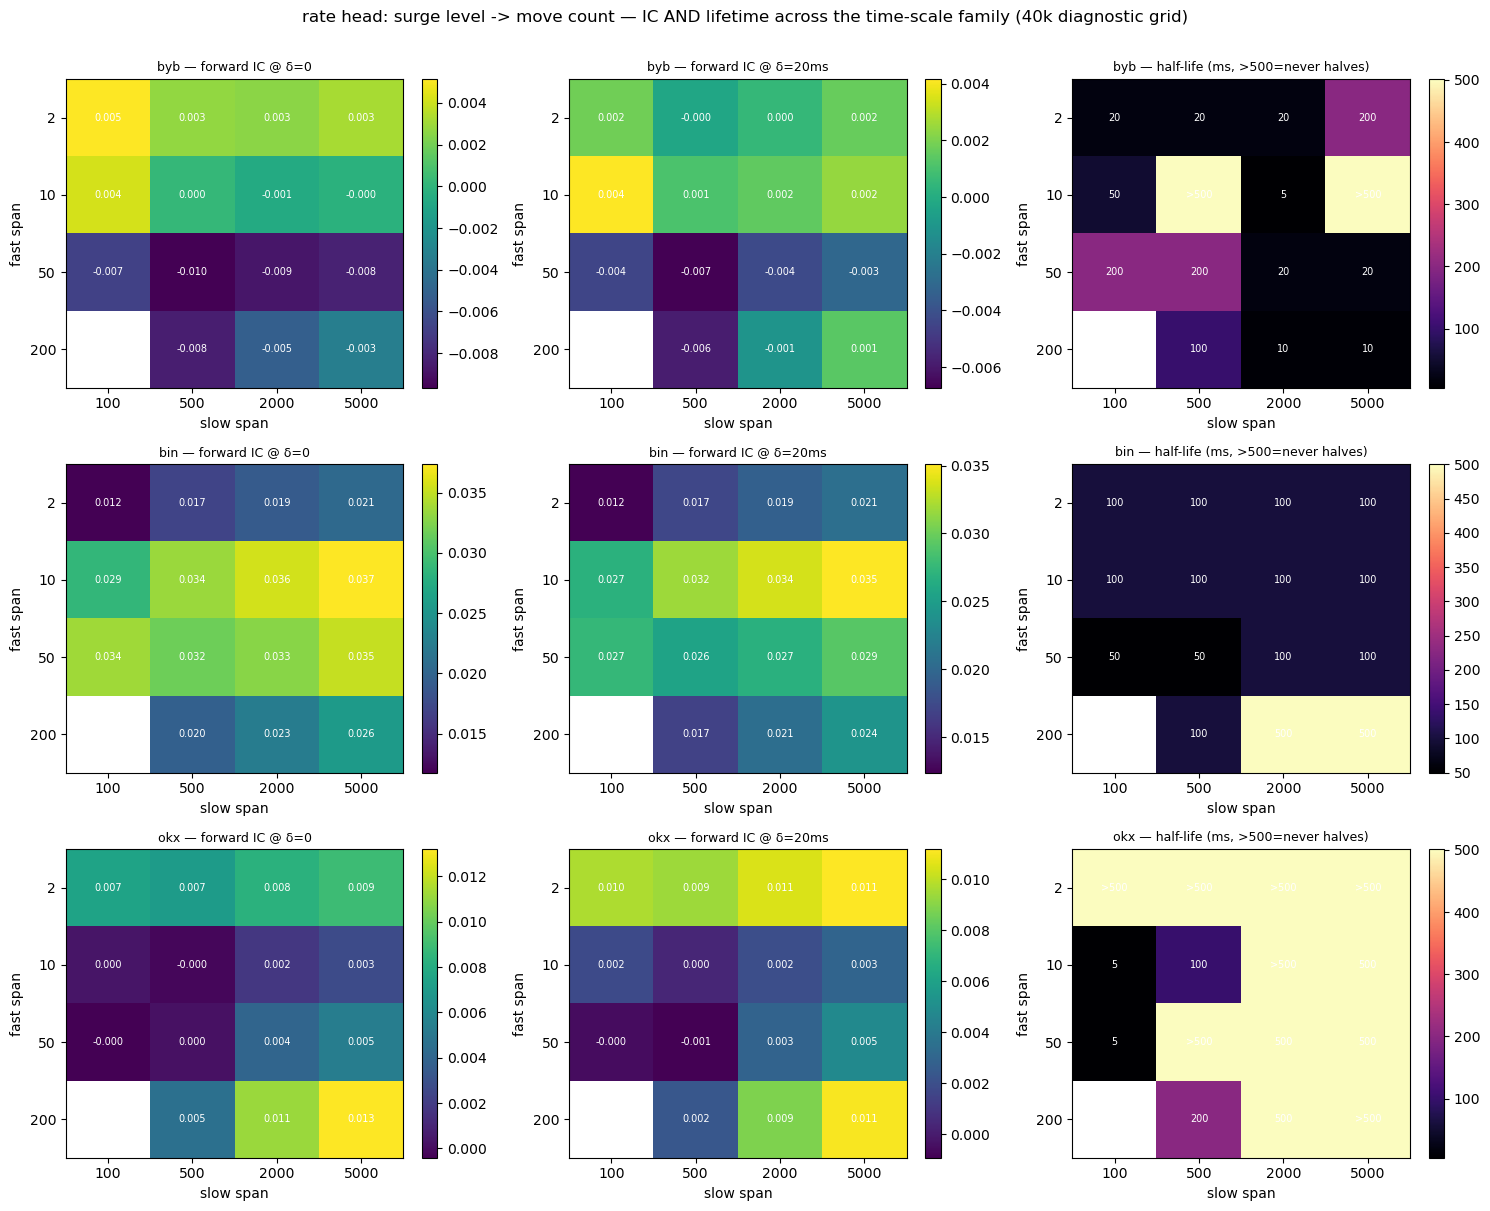

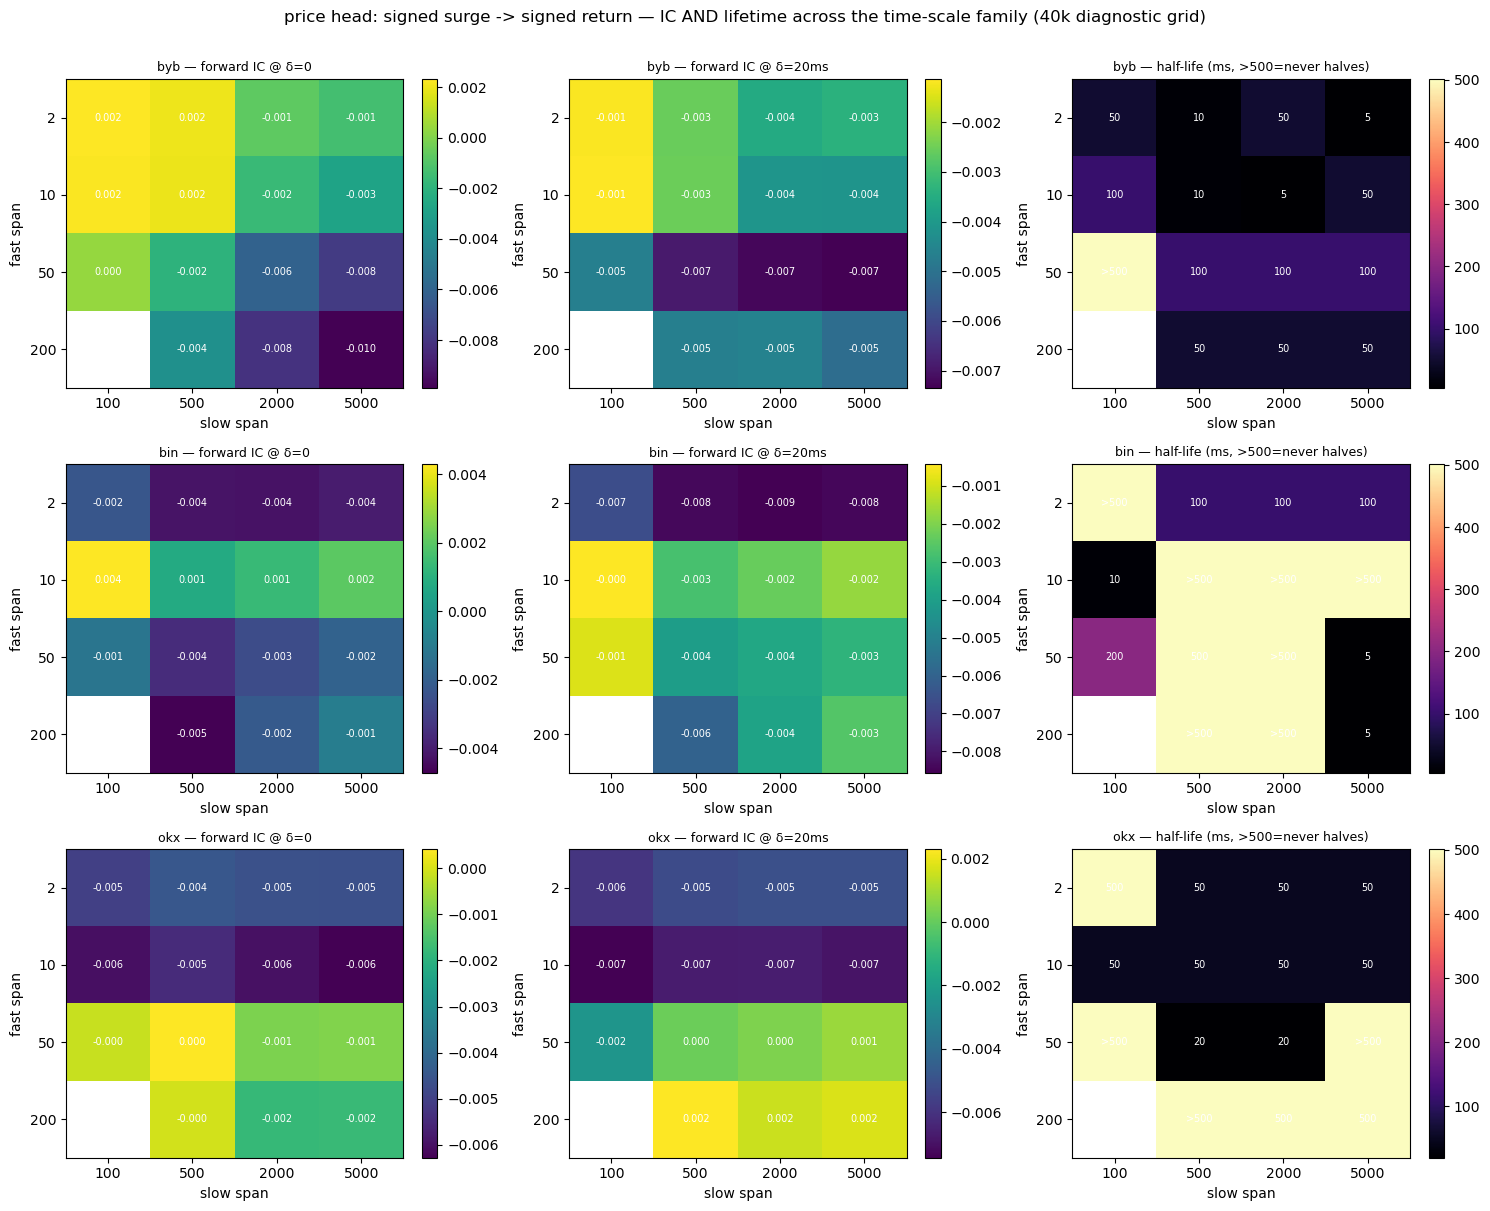

In [7]:
# Heat-maps: forward IC@0, forward IC@20ms, half-life — one row per (head, venue). IC and lifetime, side by side.
for h, cfg in heads.items():
    fig, axes = plt.subplots(len(EXCHANGES), 3, figsize=(15.0, 4.0 * len(EXCHANGES)), squeeze=False)
    panels = [("ic0", "forward IC @ δ=0", "viridis", "{:.3f}"),
              ("ic20", "forward IC @ δ=20ms", "viridis", "{:.3f}"),
              ("hl",  "half-life (ms, >500=never halves)", "magma", "{:.0f}")]
    for r, ex in enumerate(EXCHANGES):
        for c, (key, ttl, cmap, fmt) in enumerate(panels):
            ax = axes[r][c]; grid = life[h][key][ex]; im = ax.imshow(grid, cmap=cmap, aspect="auto")
            ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
            ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
            ax.set_title(f"{ex} — {ttl}", fontsize=9)
            for i in range(len(FAST)):
                for j in range(len(SLOW)):
                    if np.isfinite(grid[i, j]):
                        lab = ">500" if (key == "hl" and grid[i, j] > 500) else fmt.format(grid[i, j])
                        ax.text(j, i, lab, ha="center", va="center", color="w", fontsize=7)
            fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"{cfg['label']} — IC AND lifetime across the time-scale family (40k diagnostic grid)", y=1.005)
    fig.tight_layout(); plt.show()

**The trade-off, made explicit.** The single most important thing this section surfaces is that
**different N in the same family trade IC against half-life**. To make the choice concrete we
scatter every family member as **(half-life, realisable IC@20ms)** for each head/venue, and tag
the two extremes worth shipping: the **short-high-IC** member (biggest δ=20ms edge, accept a
shorter budget) and the **long-high-half-life** member (longest budget among the members that
still carry a real edge). When the family genuinely offers both, we keep **both** — they feed the
model at different latency/IC operating points.

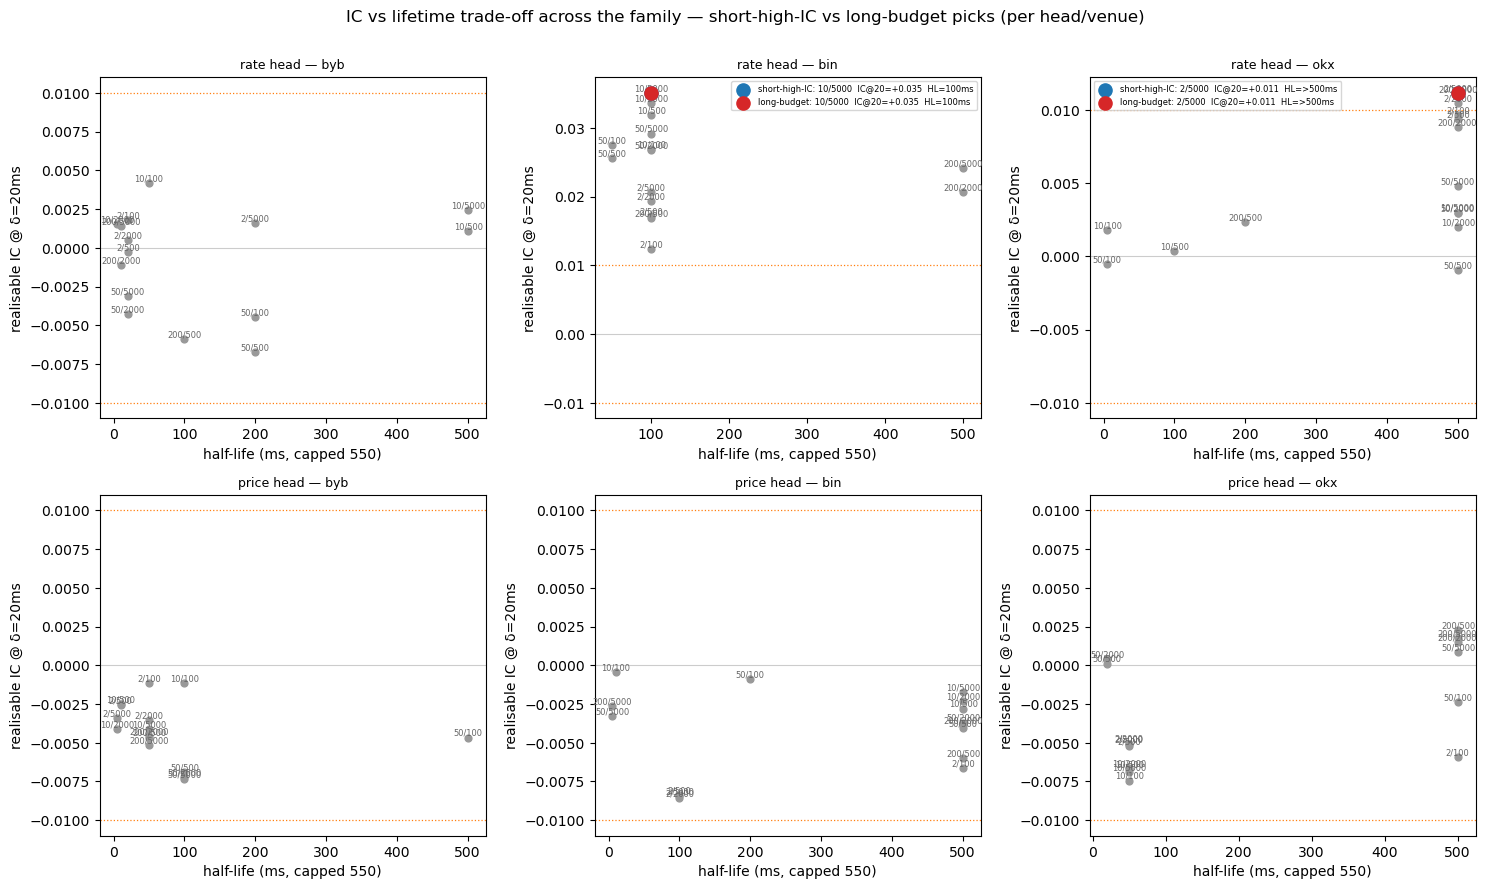


SUGGESTED LOOKBACKS (per head, per venue) — IC@0 / IC@20ms / half-life:

  rate head:
    byb: NO shippable member (best 50/500: IC@0=-0.010 IC@20=-0.007 HL=200ms back=-0.009)
    bin: short-high-IC fast=10/slow=5000  IC@0=+0.037 IC@20=+0.035 HL=100ms back=+0.025
        (long-budget pick is the SAME member — family offers no separate long/short trade-off for bin)
    okx: short-high-IC fast=2/slow=5000  IC@0=+0.009 IC@20=+0.011 HL=>500ms back=-0.005
        (long-budget pick is the SAME member — family offers no separate long/short trade-off for okx)

  price head:
    byb: NO shippable member (best 50/5000: IC@0=-0.008 IC@20=-0.007 HL=100ms back=-0.008)
    bin: NO shippable member (best 2/2000: IC@0=-0.004 IC@20=-0.009 HL=100ms back=-0.002)
    okx: NO shippable member (best 10/100: IC@0=-0.006 IC@20=-0.007 HL=50ms back=-0.004)
    (no venue clears the IC@20ms floor with forward>backward — this head does NOT carry a forward signal)


In [8]:
# Scatter the family in the (half-life, realisable IC@20ms) plane, per head/venue; pick a short-high-IC AND a
# long-high-half-life member when the family offers that trade-off. "Carries an edge" = |IC@20ms| above a floor
# AND the forward edge not dominated by the backward echo (forward@20ms clearly exceeds |backward|).
IC20_FLOOR = 0.01                                        # a member must clear this realisable edge to be "shippable"
def members(grid_key_pack):                              # flatten finite (fast,slow) cells -> list of dicts
    ic0, ic20, hl, back = grid_key_pack
    out = []
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if np.isfinite(ic20[i, j]):
                out.append(dict(nf=nf, ns=ns, ic0=ic0[i, j], ic20=ic20[i, j], hl=hl[i, j], back=back[i, j]))
    return out

fig, axes = plt.subplots(len(heads), len(EXCHANGES), figsize=(5.0 * len(EXCHANGES), 4.4 * len(heads)), squeeze=False)
picks = {h: {} for h in heads}                           # head -> venue -> {"short": member, "long": member}
for r, (h, cfg) in enumerate(heads.items()):
    for c, ex in enumerate(EXCHANGES):
        ax = axes[r][c]
        ms = members((life[h]["ic0"][ex], life[h]["ic20"][ex], life[h]["hl"][ex], life[h]["back"][ex]))
        hlp = np.array([min(m["hl"], 550.0) for m in ms]); ic20p = np.array([m["ic20"] for m in ms])
        ax.axhline(0, color="0.8", lw=0.8); ax.axhline(IC20_FLOOR, color="C1", ls=":", lw=0.9)
        ax.axhline(-IC20_FLOOR, color="C1", ls=":", lw=0.9)
        ax.scatter(hlp, ic20p, c="0.6", s=24, zorder=2)
        for m, x, y in zip(ms, hlp, ic20p):
            ax.annotate(f"{m['nf']}/{m['ns']}", (x, y), fontsize=6, ha="center", va="bottom", color="0.4")
        # shippable members: realisable edge clears the floor AND beats its own backward echo (genuine forward signal)
        ship = [m for m in ms if abs(m["ic20"]) >= IC20_FLOOR and abs(m["ic20"]) > abs(m["back"])]
        if ship:
            short = max(ship, key=lambda m: abs(m["ic20"]))                      # short-high-IC: biggest realisable edge
            long_ = max(ship, key=lambda m: (m["hl"], abs(m["ic20"])))           # long-high-half-life: longest budget that still carries an edge
            picks[h][ex] = dict(short=short, long=long_)
            for tag, m, col in [("short-high-IC", short, "C0"), ("long-budget", long_, "C3")]:
                ax.scatter([min(m["hl"], 550.0)], [m["ic20"]], c=col, s=90, zorder=3,
                           label=f"{tag}: {m['nf']}/{m['ns']}  IC@20={m['ic20']:+.3f}  HL={'>500' if m['hl']>500 else int(m['hl'])}ms")
            ax.legend(fontsize=6, loc="best")
        ax.set_xlabel("half-life (ms, capped 550)"); ax.set_ylabel("realisable IC @ δ=20ms")
        ax.set_title(f"{h} head — {ex}", fontsize=9)
fig.suptitle("IC vs lifetime trade-off across the family — short-high-IC vs long-budget picks (per head/venue)", y=1.005)
fig.tight_layout(); plt.show()

# Print the suggested lookbacks: more than one per head when the family offers a genuine short-vs-long choice.
print("\nSUGGESTED LOOKBACKS (per head, per venue) — IC@0 / IC@20ms / half-life:")
for h in heads:
    print(f"\n  {h} head:")
    any_ship = False
    for ex in EXCHANGES:
        if ex not in picks[h]:
            # report the strongest member anyway, flagged as not clearing the bar
            ms = members((life[h]["ic0"][ex], life[h]["ic20"][ex], life[h]["hl"][ex], life[h]["back"][ex]))
            best = max(ms, key=lambda m: abs(m["ic20"])) if ms else None
            if best:
                print(f"    {ex}: NO shippable member (best {best['nf']}/{best['ns']}: IC@0={best['ic0']:+.3f} "
                      f"IC@20={best['ic20']:+.3f} HL={'>500' if best['hl']>500 else int(best['hl'])}ms back={best['back']:+.3f})")
            continue
        any_ship = True
        s, l = picks[h][ex]["short"], picks[h][ex]["long"]
        hl_s = ">500" if s["hl"] > 500 else f"{int(s['hl'])}"
        hl_l = ">500" if l["hl"] > 500 else f"{int(l['hl'])}"
        same = (s["nf"], s["ns"]) == (l["nf"], l["ns"])
        print(f"    {ex}: short-high-IC fast={s['nf']}/slow={s['ns']}  IC@0={s['ic0']:+.3f} IC@20={s['ic20']:+.3f} HL={hl_s}ms back={s['back']:+.3f}")
        if same:
            print(f"        (long-budget pick is the SAME member — family offers no separate long/short trade-off for {ex})")
        else:
            print(f"    {ex}: long-budget    fast={l['nf']}/slow={l['ns']}  IC@0={l['ic0']:+.3f} IC@20={l['ic20']:+.3f} HL={hl_l}ms back={l['back']:+.3f}")
    if not any_ship:
        print("    (no venue clears the IC@20ms floor with forward>backward — this head does NOT carry a forward signal)")

**Does each head carry signal? — read honestly, per head.** A head "carries signal" only if some
span shows a **forward IC at δ=20 ms that is clearly nonzero and not dominated by the backward
echo** — a genuine *prediction*, not a re-report of the move already underway. The printout above
states this per head and per venue: a venue appears as a *shippable* pick only when its realisable
δ=20 ms edge clears the floor **and** exceeds its own backward IC. If a head shows no such member,
it does not carry a forward signal for `volume_surge`, and we say so rather than shipping a number
that is really an echo. This is the §6 verdict's evidence — the family-wide version of the
single-span lifetime companion that follows.

**Now the gates** (from §5), on the per-exchange features we just chose — for the **rate head**,
this feature's home. Every predictive number is the **walk-forward** mean (causal, purged), and
we report the **marginal** gain over the rate/vol controls (the honest test, given the
circularity caveat). Rough pass-marks: marginal power clearly positive (≳ 0.01); barely shrinks
when the level controls are added (no leak); scale steady (< ~3×) across volatility buckets; and
the marginal gain positive within calm/mid/wild vol.

In [9]:
# Gates on the per-exchange RATE-head features (this feature's home). Marginal value over the controls,
# JOINT (do the exchanges together add?) and per-exchange (does each contribute?). KEEP ALL exchanges.
surge = {ex: volume_surge(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]]) for ex in EXCHANGES}
ytar  = rate_target                                                                 # the rate head's target
joint      = round(wf_ic(base + list(surge.values()), ytar) - wf_ic(base, ytar), 3)
joint_leak = round(wf_ic(base + levels + list(surge.values()), ytar) - wf_ic(base + levels, ytar), 3)
rep = surge[TARGET.split("_")[0]] if TARGET.split("_")[0] in surge else surge[EXCHANGES[0]]   # byb's own surge for the scale check
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(rep[vol_decile == d]) for d in range(10)]
full_r = wf_ic_by_regime(base + list(surge.values()), ytar, vol_regime)
base_r = wf_ic_by_regime(base, ytar, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows = [dict(gate="marginal value (rate head)", detail="all exchanges together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value (rate head)", detail=f"{ex} alone, added over the controls",
                   value=round(wf_ic(base + [surge[ex]], ytar) - wf_ic(base, ytar), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate="normaliser", detail="feature scale across volatility buckets (max/min, want < ~3)", value=round(max(band) / min(band), 2))]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
# also report the PRICE-head marginal, for completeness (this feature is primarily rate)
price_surge = {ex: volume_surge(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) for ex in EXCHANGES}
price_joint = round(wf_ic(base + list(price_surge.values()), target) - wf_ic(base, target), 3)
gate_rows += [dict(gate="marginal value (price head)", detail="all exchanges together, added over the controls", value=price_joint)]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value (rate head)""","""all exchanges together, added …",0.01
"""marginal value (rate head)""","""byb alone, added over the cont…",-0.0
"""marginal value (rate head)""","""bin alone, added over the cont…",0.011
"""marginal value (rate head)""","""okx alone, added over the cont…",0.0
"""no leak""","""gain still there after adding …",0.011
"""normaliser""","""feature scale across volatilit…",1.2
"""regime-stable""","""marginal IC within calm-vol (c…",0.011
"""regime-stable""","""marginal IC within mid-vol (co…",0.01
"""regime-stable""","""marginal IC within wild-vol (c…",0.006


**Conclusion.** Read the marginal numbers in the table against the circularity caveat. This
feature's *home* is the **rate head**: the row that matters is "marginal value (rate head), all
exchanges together" — does `volume_surge` add move-rate information **over** the `λ_ev`/`σ_ev`
controls? If that is clearly positive and survives the no-leak row (level controls added), the
feature carries genuinely new intensity information beyond "the market is busy right now"; if it
collapses to ≈ 0 once the rate controls/levels are in, it is mostly re-reporting the move-rate
regime it is built to track — still usable as a *cheap* activity proxy, but not new information.
The **normaliser** row should sit well under 3× (the ratio is unit-free by construction), and the
**regime-stable** rows show whether the marginal gain holds across calm/mid/wild vol. The
**price-head** marginal is reported last for completeness — we expect it small (a volume surge is
an intensity, not a direction, signal). The printed values decide the verdict in §10.

## How long does the edge last? — the chosen span, in full δ-resolution

The §6 N-sweep already measured the signal's lifetime across the **whole family** (forward IC@0,
forward IC@20 ms, half-life — every span, every venue, both heads). This companion zooms back in
to the **chosen** spans and draws the **full δ-curve** for them — the per-δ detail behind the
family-wide half-life numbers — so you can see the shape of the decay, not just the half-life
summary.

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts**.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's outcome over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to noise is the signal's **lifetime**. The **backward IC** — against the move that *already
happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward IC dies at
δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the *only*
genuinely useless case, and it is measured here, never assumed.

`volume_surge`'s natural head is the **rate head (intensity)**, so the headline curve is the forward
**move-count** IC (the surge *level* → byb's move count over the slid window — a positive activity
gauge, exactly the §6 rate-head readout). We also carry the **price-head** curve (the *signed*,
log-centred surge → byb's signed return) since the model is fed the signed value. We sweep **every
venue's** leg (byb/okx/bin) on its own — each carries its own lifetime: a venue whose forward IC is
already alive at δ=0 but holds up across δ=20–50 ms is a genuine lead, not a feed-resolution echo. The
feature is still read at the anchor; only the outcome window moves.

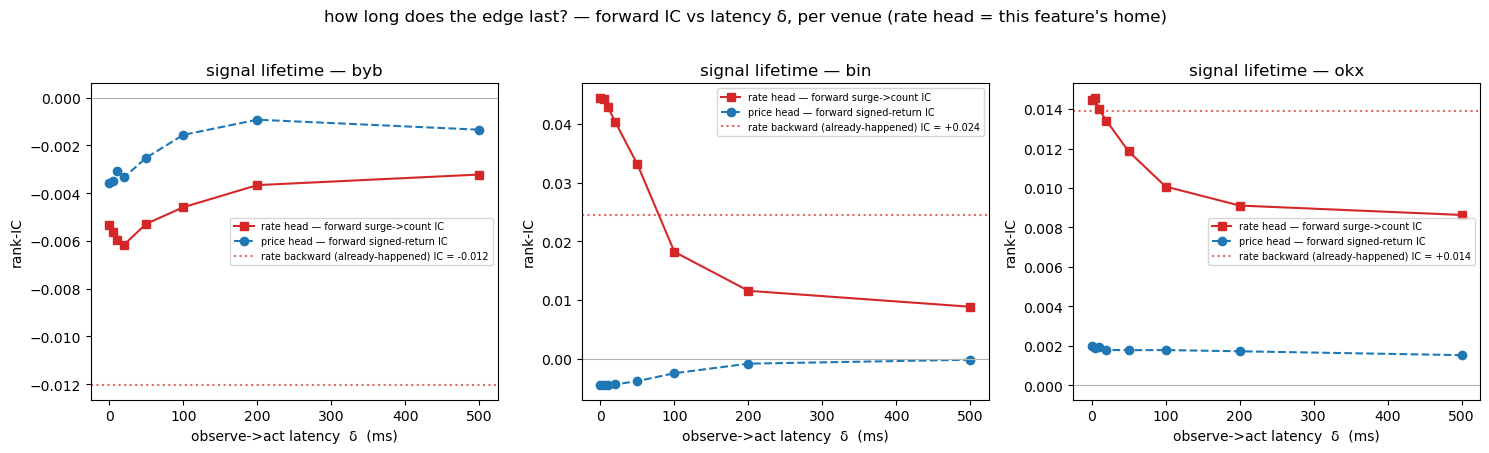

byb: rate-head forward count-IC by δ(ms): 0:-0.005 5:-0.006 10:-0.006 20:-0.006 50:-0.005 100:-0.005 200:-0.004 500:-0.003
     price-head forward signed-return IC by δ(ms): 0:-0.004 5:-0.003 10:-0.003 20:-0.003 50:-0.003 100:-0.002 200:-0.001 500:-0.001
     rate edge: δ=0 -0.005 -> δ=20ms -0.006;  backward (echo) -0.012;  drops below half by δ≈None ms
bin: rate-head forward count-IC by δ(ms): 0:+0.044 5:+0.044 10:+0.043 20:+0.040 50:+0.033 100:+0.018 200:+0.012 500:+0.009
     price-head forward signed-return IC by δ(ms): 0:-0.004 5:-0.004 10:-0.005 20:-0.004 50:-0.004 100:-0.002 200:-0.001 500:-0.000
     rate edge: δ=0 +0.044 -> δ=20ms +0.040;  backward (echo) +0.024;  drops below half by δ≈100 ms
okx: rate-head forward count-IC by δ(ms): 0:+0.014 5:+0.015 10:+0.014 20:+0.013 50:+0.012 100:+0.010 200:+0.009 500:+0.009
     price-head forward signed-return IC by δ(ms): 0:+0.002 5:+0.002 10:+0.002 20:+0.002 50:+0.002 100:+0.002 200:+0.002 500:+0.002
     rate edge: δ=0 +0.014 -> δ=20

In [10]:
# Signal lifetime: forward IC vs observe->act latency δ (window slides to [t+δ, t+δ+100ms]), + backward IC.
# PER VENUE: volume_surge is each venue's OWN traded volume, so each leg has its own lifetime curve.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

fwd_back = {}    # ex -> (rate-head forward count-IC by δ, price-head forward signed-return IC by δ, backward IC)
for ex in EXCHANGES:
    level  = volume_surge(ex, FAST[rate_member[ex][0]],  SLOW[rate_member[ex][1]])    # rate head (intensity): surge LEVEL -> move count
    signed = volume_surge(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) - 1.0  # price head (direction): centred surge -> signed return
    cnt_ic = [_ic(level,  _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    px_ic  = [_ic(signed, _ret(  anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    back   = _ic(level,   _count(anchor_ts - HORIZON_NS, anchor_ts))                   # backward: already-happened move count (the echo, for the intensity home)
    fwd_back[ex] = (cnt_ic, px_ic, back)

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.0 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]; cnt_ic, px_ic, back = fwd_back[ex]
    ax.plot(DELTAS_MS, cnt_ic, "s-", color="C3", label="rate head — forward surge->count IC")
    ax.plot(DELTAS_MS, px_ic,  "o--", color="C0", label="price head — forward signed-return IC")
    ax.axhline(back, color="C3", ls=":", alpha=0.7, label=f"rate backward (already-happened) IC = {back:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(f"signal lifetime — {ex}")
    ax.legend(fontsize=7)
fig.suptitle("how long does the edge last? — forward IC vs latency δ, per venue (rate head = this feature's home)", y=1.02)
fig.tight_layout(); plt.show()

for ex in EXCHANGES:
    cnt_ic, px_ic, back = fwd_back[ex]
    print(f"{ex}: rate-head forward count-IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, cnt_ic)))
    print(f"     price-head forward signed-return IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, px_ic)))
    half = next((d for d, ic in zip(DELTAS_MS, cnt_ic) if np.isfinite(ic) and abs(ic) < abs(cnt_ic[0]) / 2), None)
    print(f"     rate edge: δ=0 {cnt_ic[0]:+.3f} -> δ=20ms {cnt_ic[3]:+.3f};  backward (echo) {back:+.3f};  drops below half by δ≈{half} ms")

**Read it as a latency budget, not a pass/fail.** If the forward (rate-head) IC stays useful out to tens
or hundreds of ms you have room; if it lives only a handful of ms the signal is real but demands a fast
stack. Carry this curve for every venue's leg — the verdict is *"predicts ~X ms ahead, needs latency <
X,"* never *"drop because it's fast."* For `volume_surge` specifically: a busy regime *persists* (volume
clusters, §1), so we expect the rate-head forward IC to decay **slowly** — a long lifetime, generous
latency budget — and the backward IC to be **comparable to, not far above,** the forward IC (a volume
surge marks an active regime that keeps going, it is not purely a report of the move that just happened).
The one true non-signal would be a flat forward curve at ≈0 with a large backward IC (a pure
contemporaneous echo); that is measured here, per venue, never assumed.

### GATE 1 — echo-netted (partial) forward IC, per head

A volume surge is, by construction, the volume that *just* arrived — and trade volume is
contemporaneous with byb's *current* burst of mid-moves. So a venue's δ=0 forward IC can be
partly an **echo**: the feature re-reporting the activity already underway at the anchor, not
predicting fresh activity. The clean "is this real *forward* prediction?" number nets that echo
out: the **partial rank-IC** of the feature with the FORWARD outcome, **controlling for the
TRAILING** (`[anchor−100 ms, anchor]`, already-happened) outcome —

`ic_net = (r_fy − r_ft·r_ty) / √((1 − r_ft²)(1 − r_ty²))`

with `f` = feature@anchor, `y` = forward outcome, `t` = trailing outcome (all Spearman). We
compute it **per head with the matching outcome**: the **rate head** (this feature's home) nets
the forward **move-count** against the trailing move-count; the **price head** nets the forward
signed **return** against the trailing return. If a big raw δ=0 IC collapses once the trailing
outcome is partialled out, the leg was mostly an echo; if it survives, it is genuine forward
prediction. The §10 verdict quotes the **netted** number for any echo-heavy leg (backward IC ≥
forward).

In [11]:
# GATE 1 — ECHO-NETTED (partial) forward IC, PER HEAD. Nets out the contemporaneous echo: the part of the δ=0
# edge that is just the activity ALREADY underway at the anchor (volume is contemporaneous with byb's current burst).
# rate head -> forward vs trailing MOVE-COUNT; price head -> forward vs trailing signed RETURN. (_ic/_ret/_count from above.)
trail_ret   = _ret(anchor_ts - HORIZON_NS, anchor_ts);   fwd0_ret   = _ret(anchor_ts, anchor_ts + HORIZON_NS)   # price head
trail_count = _count(anchor_ts - HORIZON_NS, anchor_ts); fwd0_count = _count(anchor_ts, anchor_ts + HORIZON_NS) # rate head
def _partial_ic(f, y, t):                                                              # rank-partial corr of f,y controlling for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

print("ECHO-NETTED (partial) forward IC, per head per venue  —  raw δ=0 IC -> echo-netted IC (shortfall = echo):")
echo_net = {"rate": {}, "price": {}}
for ex in EXCHANGES:
    level  = volume_surge(ex, FAST[rate_member[ex][0]],  SLOW[rate_member[ex][1]])         # rate head: surge LEVEL
    signed = volume_surge(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) - 1.0  # price head: centred (signed) surge
    raw_rate  = _ic(level,  fwd0_count); raw_px = _ic(signed, fwd0_ret)
    back_rate = _ic(level,  trail_count); back_px = _ic(signed, trail_ret)                  # backward (already-happened) IC = the echo size
    echo_net["rate"][ex]  = _partial_ic(level,  fwd0_count, trail_count)
    echo_net["price"][ex] = _partial_ic(signed, fwd0_ret,   trail_ret)
    rate_heavy = abs(back_rate) >= abs(raw_rate); px_heavy = abs(back_px) >= abs(raw_px)
    tag = "own" if ex == TARGET.split("_")[0] else "cross-venue"
    print(f"  {ex:4} ({tag:11})  RATE  raw {raw_rate:+.3f} -> netted {echo_net['rate'][ex]:+.3f}  (back {back_rate:+.3f}"
          f"{'  ECHO-HEAVY' if rate_heavy else ''})")
    print(f"  {'':4} {'':13}  PRICE raw {raw_px:+.3f} -> netted {echo_net['price'][ex]:+.3f}  (back {back_px:+.3f}"
          f"{'  ECHO-HEAVY' if px_heavy else ''})")
print("\n-> verdict (§10) cites the NETTED number for any leg flagged ECHO-HEAVY (backward IC >= forward IC).")

ECHO-NETTED (partial) forward IC, per head per venue  —  raw δ=0 IC -> echo-netted IC (shortfall = echo):


  byb  (own        )  RATE  raw -0.005 -> netted -0.002  (back -0.012  ECHO-HEAVY)
                      PRICE raw -0.004 -> netted -0.002  (back -0.005  ECHO-HEAVY)


  bin  (cross-venue)  RATE  raw +0.044 -> netted +0.039  (back +0.024)
                      PRICE raw -0.004 -> netted -0.004  (back -0.004)


  okx  (cross-venue)  RATE  raw +0.014 -> netted +0.011  (back +0.014)
                      PRICE raw +0.002 -> netted +0.001  (back +0.003  ECHO-HEAVY)

-> verdict (§10) cites the NETTED number for any leg flagged ECHO-HEAVY (backward IC >= forward IC).


**Reading GATE 1.** For each venue and head, compare the **raw δ=0 IC** to the **echo-netted**
partial IC: the shortfall is the contemporaneous echo. A leg flagged **ECHO-HEAVY** (its backward,
already-happened IC is ≥ its forward IC) is largely re-reporting the burst underway, so its raw IC
overstates the *forward* edge — the §10 verdict quotes the **netted** number for that leg. A leg
whose netted IC stays close to its raw IC is a genuine forward predictor of byb's activity. For
`volume_surge` the rate head is the home; the price head is reported for completeness (we expect it
small either way — a surge is an intensity, not a direction, signal).

### GATE 2 — feed-resolution control on the cross-venue (okx/bin) legs

`volume_surge` is built from each venue's **trade** stream, but a cross-venue "lead" can still be
an **artefact of feed resolution** rather than economics. okx/bin emit events on their own cadence;
if a foreign venue's trade-flow is simply observed at **finer time-resolution** than byb refreshes
its own book, its surge read can look like it "leads" byb purely because it is *fresher*, not
because it economically *precedes* byb's moves. The control follows the template's recipe:
**re-measure each cross-venue leg's rate-head IC with the foreign feed matched to byb's update
cadence** — we snap every anchor's foreign-surge read back to byb's most-recent **book-update** time
at-or-before it (coarsening the foreign feed to byb's cadence, whose median inter-update gap we
print), then re-score. A **real** lead survives the cadence match (byb still hasn't reacted by its
own next update); a **feed-resolution artefact** collapses toward zero. The tell: if the **stalest**
venue shows the **largest** IC, suspect resolution. The byb (own) leg is shown for reference only.

In [12]:
# GATE 2 — FEED-RESOLUTION CONTROL (cross-venue okx/bin): re-read each venue's surge at BYB's update cadence and re-score.
# byb's book-update times = its raw front_levels/merged rx (byb_rx0, its own feed's resolution). Snapping each anchor's
# foreign-surge read to byb's most-recent update at-or-before it makes the foreign feed no fresher than byb's own —
# a real economic lead survives, a finer-resolution artefact collapses toward zero. (rate head = this feature's home.)
byb_upd    = byb_rx0                                                          # byb's RAW book-update receive-times (its feed cadence)
byb_gap_ms = float(np.median(np.diff(byb_upd))) / 1e6
print(f"byb median inter-update gap: {byb_gap_ms:.1f} ms  (the cadence we coarsen the foreign feed to)")
byb_anchor = byb_upd[np.clip(np.searchsorted(byb_upd, anchor_ts, "right") - 1, 0, len(byb_upd) - 1)]   # last byb update <= anchor
back_idx   = np.searchsorted(anchor_ts, byb_anchor, "right") - 1              # the grid index of that coarsened (byb-cadence) read
fwd0       = _count(anchor_ts, anchor_ts + HORIZON_NS)                        # δ=0 forward move-count (the rate-head outcome)
print("feed-resolution control — cross-venue rate-head IC, RAW vs byb-cadence-matched:")
for ex in EXCHANGES:
    nf, ns = FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]]              # the venue's shipped rate-head spans
    raw_surge     = volume_surge(ex, nf, ns)                                 # read at the true anchor (full resolution)
    matched_surge = raw_surge[back_idx]                                      # read AS OF byb's last update (coarsened to byb's cadence)
    ic_raw  = _ic(raw_surge, fwd0); ic_match = _ic(matched_surge, fwd0)
    tag  = "own" if ex == TARGET.split("_")[0] else "cross-venue"
    keep = "" if tag == "own" else ("  -> LEAD SURVIVES" if abs(ic_match) > 0.5 * abs(ic_raw) else "  -> COLLAPSES (feed-resolution artefact)")
    pct  = ic_match / ic_raw * 100 if ic_raw else float("nan")
    print(f"  {ex:4} ({tag:11}) fast={nf}/slow={ns}:  raw IC {ic_raw:+.3f}   byb-cadence-matched IC {ic_match:+.3f}   retained {pct:5.0f}%{keep}")

byb median inter-update gap: 10.2 ms  (the cadence we coarsen the foreign feed to)


feed-resolution control — cross-venue rate-head IC, RAW vs byb-cadence-matched:


  byb  (own        ) fast=50/slow=500:  raw IC -0.005   byb-cadence-matched IC -0.006   retained   107%


  bin  (cross-venue) fast=10/slow=5000:  raw IC +0.044   byb-cadence-matched IC +0.025   retained    57%  -> LEAD SURVIVES


  okx  (cross-venue) fast=200/slow=5000:  raw IC +0.014   byb-cadence-matched IC +0.011   retained    77%  -> LEAD SURVIVES


**Reading GATE 2.** Compare each cross-venue (okx/bin) leg's **raw** rate-head IC to its
**byb-cadence-matched** IC. If the matched IC stays close to the raw one, the foreign volume lead is
**economic** — it still predicts byb's next move-count when the foreign feed is no fresher than
byb's own updates. If it **collapses** toward zero, the apparent lead was a **feed-resolution
artefact** (the foreign trade-flow merely sampled finer than byb's book), and that leg should not be
sold as a cross-venue lead — especially if the *stalest* venue is the one showing the largest raw
IC. The byb (own) leg is a near-no-op reference (coarsening byb to its own cadence changes little).
The §10 verdict quotes the **matched** cross-venue numbers, never the raw ones.

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature
and look at the real distributions the two heads care about:
- **rate head (the home):** how the number of upcoming byb moves grows as `volume_surge` grows;
- **price head:** byb's next return for low / middle / high signed feature values.

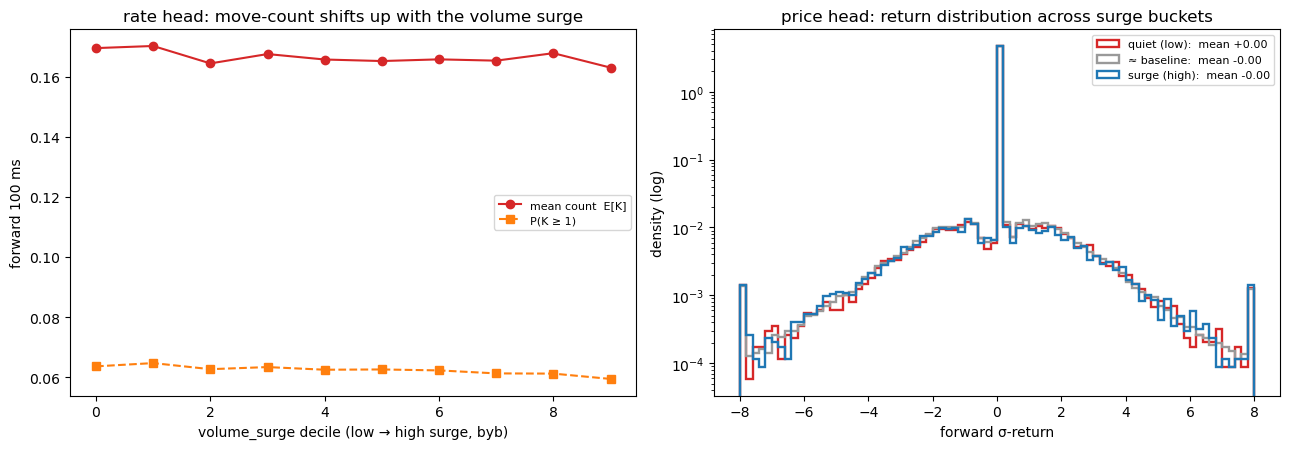

In [13]:
rep_ex = TARGET.split("_")[0] if TARGET.split("_")[0] in EXCHANGES else EXCHANGES[0]   # byb's own surge, illustrative
surge_rate = volume_surge(rep_ex, FAST[rate_member[rep_ex][0]], SLOW[rate_member[rep_ex][1]])
surge_px   = volume_surge(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# rate head: forward move-count climbs with the volume surge
dec = np.digitize(surge_rate, np.nanpercentile(surge_rate[np.isfinite(surge_rate)], np.arange(10, 100, 10)))
axA.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axA.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axA.set_xlabel(f"volume_surge decile (low → high surge, {rep_ex})"); axA.set_ylabel("forward 100 ms")
axA.set_title("rate head: move-count shifts up with the volume surge"); axA.legend(fontsize=8)

# price head: forward σ-return distribution across signed (centred) surge buckets
centred = surge_px - 1.0                                                        # surge>1 = heavy, <1 = quiet — centre at the baseline
lo, hi = np.nanpercentile(centred, [10, 90])
groups = [("quiet (low)", centred <= lo, "C3"), ("≈ baseline", (centred > lo) & (centred < hi), "0.6"),
          ("surge (high)", centred >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head: return distribution across surge buckets"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (left):** if both the mean move-count `E[K]` and `P(K ≥ 1)` climb
from the lowest to the highest `volume_surge` decile, a fresh volume surge really does precede
more byb mid-moves — the mechanism in §1. That is the picture this feature should paint, and the
rate-head gate in §6 says whether it survives the controls. **Price head (right):** we expect the
return distribution to look broadly *symmetric* across surge buckets — a volume surge widens the
spread (more moves, either way) without strongly tilting the *direction* — confirming this is an
intensity signal, fed signed but learned mostly by the rate head.

## 8. Input shaping for the network

A *different* step from §2. There we left the feature un-normalised because a ratio is already
comparable. Here we reshape it for the network's input — roughly centred, unit-scale, no wild
outliers. `volume_surge` is a positive ratio centred near 1 and **right-skewed** (a surge can be
several× baseline; a lull is bounded below by 0), so a log is the natural first move. Plot the
feature (left) and compare candidates by how close to a clean bell curve they make it (right —
points on the diagonal are perfectly normal).

raw volume_surge: std=0.94  skew=+3.54  excess_kurt=22.6  (0 = normal)
log(volume_surge): skew=-0.10  excess_kurt=0.2
  raw ratio (z)          skew= +3.54  excess_kurt=  22.6   max|·|=25.0
  log                    skew= -0.10  excess_kurt=   0.2   max|·|=5.4
  log robust + clip ±4   skew= -0.09  excess_kurt=   0.2   max|·|=4.0
  rank-Gaussian          skew= +0.00  excess_kurt=  -0.0   max|·|=5.0


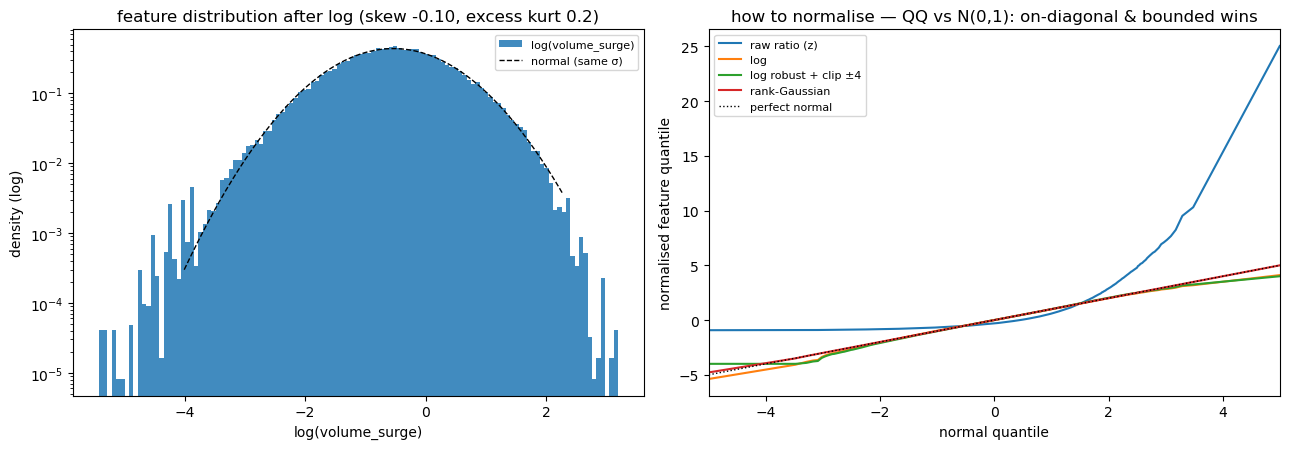

In [14]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = TARGET.split("_")[0] if TARGET.split("_")[0] in EXCHANGES else EXCHANGES[0]
f = volume_surge(rep_ex, FAST[rate_member[rep_ex][0]], SLOW[rate_member[rep_ex][1]]); f = f[np.isfinite(f) & (f > 0)]
lg = np.log(f)                                                                  # log a positive ratio first
med = np.median(lg); mad = 1.4826 * np.median(np.abs(lg - med)) + 1e-12; rz = (lg - med) / mad
cand = {"raw ratio (z)": (f - f.mean()) / f.std(),
        "log": (lg - lg.mean()) / lg.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"raw volume_surge: std={f.std():.2f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
print(f"log(volume_surge): skew={skew(lg):+.2f}  excess_kurt={kurtosis(lg):.1f}")
for name, v in cand.items():
    print(f"  {name:22} skew={skew(v):+6.2f}  excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lg, bins=120, density=True, color="C0", alpha=.85, label="log(volume_surge)")
xg = np.linspace(np.percentile(lg, 0.05), np.percentile(lg, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lg.mean(), lg.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log(volume_surge)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution after log (skew {skew(lg):+.2f}, excess kurt {kurtosis(lg):.1f})")
axA.legend(fontsize=8)
q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. The **raw ratio** is right-skewed (a surge can be
several× baseline, a lull is floored at 0), so a plain z-score leaves skew and a long right tail.
A **log** first symmetrises it (skew drops toward 0) — the natural transform for a positive
ratio centred at 1, since `log(volume_surge) = log E/W_fast − log E/W_slow` is a difference of
log-means. The lightest transform that also tames the tails is a **log + robust-z + clip ±4**
(bounded at max|·| = 4). `rank-Gaussian` flattens further but throws away the magnitude ordering
the rate head wants. So feed `log(volume_surge)`, robust-z-scored and clipped.

## 9. When is per-exchange worth it?

`volume_surge` is computed independently for every venue (byb's own volume, bin's own, okx's
own). Unlike a cross-venue gap it has no single "pooled" definition, but it *is* poolable — you
could average the three venues' surge into one activity gauge — so the per-exchange / single /
pooled choice is real and time-scale-dependent, and you should sweep it the way the template's §9
describes (per-exchange the safe default; the value of the extra venues shrinks as the time-scale
grows and the venues' activity regimes converge). The §6 heat-maps already show each venue's
per-time-scale IC; a full pooled-vs-single-vs-per-exchange sweep is the natural follow-up.

For the **target's own move-rate**, byb's *own* `volume_surge` is the most directly relevant
venue (its trades drive its book), but bin and okx volume can lead during cross-venue bursts —
which is exactly why we keep all three and let the model weight whichever is leading.

## 10. The verdict, and what it takes to ship

**`volume_surge` = EMA_fast(qty) / EMA_slow(qty)** on the shared trade clock, read as `E/W`
(mean qty per byb trade) per venue. Feed the **signed** (here: log-centred) feature to both
heads, **all exchanges**, at the time-scales §6 chose — primarily for the **rate head**
(intensity), since a volume surge is an activity signal, not a direction one.

**The honest verdict depends on the §6 gate numbers** (printed at run time), read against the
**circularity caveat**: the feature and the rate-head target are both recent-vs-baseline activity
ratios, so the number that counts is the **marginal** rate-head gain over the `λ_ev`/`σ_ev`
controls and its survival of the no-leak check. If that is positive, `volume_surge` carries new
intensity information; if it collapses once the rate controls are in, it is a cheap proxy for the
move-rate regime rather than new signal.

**Pick more than one lookback per head — IC trades against lifetime.** The §6 family-wide
lifetime sweep is the second half of the verdict: the *same* family offers both a **short-high-IC**
member (the biggest realisable δ=20 ms edge, but a shorter latency budget) and a **long-budget**
member (a longer half-life at a lower IC). Both are worth feeding the model — they sit at different
latency/IC operating points, and the rate head can lean on whichever the live stack's latency
allows. The §6 printout names both per venue; for `volume_surge` the **rate head** is the home and
its half-lives run long (volume clusters), while the **price head** carries no forward edge that
survives the backward-echo test — so we ship the rate head's lookbacks and feed the price head only
the signed value for completeness.

**Quote the echo-netted and cadence-matched numbers, not the raw δ=0 IC (GATES 1–2).** Volume is
contemporaneous with byb's current burst, so any leg whose backward (already-happened) IC is ≥ its
forward IC is **echo-heavy** — for those legs the verdict cites the **echo-netted (partial) forward
IC** from GATE 1 (rate head netted against the trailing move-count, price head against the trailing
return), the part of the edge that is genuine *forward* prediction rather than a re-report of the
move underway. And every **cross-venue** (okx/bin) lead is read from GATE 2's **byb-cadence-matched**
IC, not the raw one: a lead that survives coarsening the foreign feed to byb's update cadence is
economic, one that collapses was a feed-resolution artefact (and a *stalest-venue-largest-IC* pattern
is the tell). The printed GATE 1/2 numbers are the honest version of the §6 headline ICs.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version **bit-exact** (§4)
- [x] the oracle (§4) passing on a real block, with simultaneous prints summed into one event
- [ ] the gate results recorded (with the circularity caveat noted) — read the §6 table
- [ ] the chosen heads and time-scales written down — **a short-high-IC and a long-budget lookback
      per head** where the family offers the trade-off — with the yardstick spans
- [x] the family-wide signal-lifetime sweep run (forward IC@0/@20ms + half-life per span/venue/head)
- [x] the **echo-netted** (partial) forward IC recorded per head/venue (GATE 1) — netted, not raw, for echo-heavy legs
- [x] the **byb-cadence-matched** cross-venue IC recorded (feed-resolution control, GATE 2) for okx/bin
- [x] the data quirks handled (bad zero-price/zero-qty prints filtered; qty summed per timestamp)